In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, NullFormatter, ScalarFormatter
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn.objects as so
import math


cpu = pd.read_csv("../results/scaling.csv", skip_blank_lines=True)
cpu["cells"] = [int(x.rsplit("/", 2)[1]) ** 3 for x in cpu["case_long"]]
cpu["ms_normed"] = cpu["time_mean_ms"] / cpu["cells"]
strategies = list(cpu["strategy"].unique())
cpu = cpu[cpu["executor"] == "cpu"]
gpu = cpu[cpu["executor"] == "gpu"]
cpu["Threads"] = [
    int(x.split("-")[1]) if x.split("-")[1] != "serial" else 1 for x in cpu["variant"]
]
cpu["cellsPerCpu"] = cpu["cells"] / cpu["Threads"]
cpu["logth"] = [int(math.log2(x)) for x in cpu["Threads"]]
group_cols = [
    "case_long",
    "strategy",
    "language",
    "precision",
    "executor",
    "use_kernelAbstractions",
    "use_fusing",
]

baseline = (
    cpu[cpu["variant"].str.contains("serial")]
    .groupby(group_cols, as_index=False)["time_mean_ms"]
    .first()
    .rename(columns={"time_mean_ms": "serial_time"})
)

cpu = cpu.merge(baseline, on=group_cols, how="left")
cpu["speedup"] = cpu["serial_time"] / cpu["time_mean_ms"]
cpu["efficiency"] = cpu["speedup"] / cpu["Threads"]

sb.set_theme()
cpu["logthp1"] = cpu["logth"] + 1


In [2]:
cpu

,time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case_short,case_long,strategy,variant,language,precision,...,use_fusing,cells,ms_normed,Threads,cellsPerCpu,logth,serial_time,speedup,efficiency,logthp1
0,9.788398,9.778989,0.0,0.0,cases/Lid-Driven-Cavities/100/,cases/Lid-Driven-Cavities/100/,faceBased,SOAFusedFaceBasedAssembly-serial,julia,float64,...,True,1000000,0.000010,1,1000000.0,0,9.788398,1.000000,1.000000,1
1,14.669528,14.605256,0.0,0.0,cases/Lid-Driven-Cavities/100/,cases/Lid-Driven-Cavities/100/,globalFaceBased,FusedGlobalFaceBased-serial,julia,float64,...,True,1000000,0.000015,1,1000000.0,0,14.669528,1.000000,1.000000,1
2,39.010220,38.944776,0.0,0.0,cases/Lid-Driven-Cavities/100/,cases/Lid-Driven-Cavities/100/,batchedFace,FusedBatchedFaceBased-serial,julia,float64,...,True,1000000,0.000039,1,1000000.0,0,39.010220,1.000000,1.000000,1
3,41.356421,41.303329,0.0,0.0,cases/Lid-Driven-Cavities/100/,cases/Lid-Driven-Cavities/100/,cellBased,FusedCellBased-serial,julia,float64,...,True,1000000,0.000041,1,1000000.0,0,41.356421,1.000000,1.000000,1
4,18.451786,18.412309,0.0,0.0,cases/Lid-Driven-Cavities/100/,cases/Lid-Driven-Cavities/100/,faceBased,SOAFusedFaceBasedAssemblyThreaded-2,julia,float64,...,True,1000000,0.000018,2,500000.0,1,9.788398,0.530485,0.265243,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,8.577562,8.132132,0.0,0.0,cases/Lid-Driven-Cavities/80/,cases/Lid-Driven-Cavities/80/,cellBased,FusedCellBased-128,julia,float64,...,True,512000,0.000017,128,4000.0,7,21.851823,2.547556,0.019903,8
356,11.039399,10.073415,0.0,0.0,cases/Lid-Driven-Cavities/80/,cases/Lid-Driven-Cavities/80/,faceBased,SOAFusedFaceBasedAssemblyThreaded-256,julia,float64,...,True,512000,0.000022,256,2000.0,8,5.079225,0.460100,0.001797,9
357,10.483474,9.409002,0.0,0.0,cases/Lid-Driven-Cavities/80/,cases/Lid-Driven-Cavities/80/,globalFaceBased,FusedGlobalFaceBased-256,julia,float64,...,True,512000,0.000020,256,2000.0,8,7.472391,0.712778,0.002784,9
358,52.906521,52.120709,0.0,0.0,cases/Lid-Driven-Cavities/80/,cases/Lid-Driven-Cavities/80/,batchedFace,FusedBatchedFaceBased-256,julia,float64,...,True,512000,0.000103,256,2000.0,8,20.146596,0.380796,0.001487,9


In [3]:
strategies

['faceBased', 'globalFaceBased', 'batchedFace', 'cellBased']

In [4]:
sorted(cpu["cells"].unique())

[np.int64(8000),
 np.int64(64000),
 np.int64(216000),
 np.int64(512000),
 np.int64(1000000),
 np.int64(1728000),
 np.int64(2744000),
 np.int64(4096000),
 np.int64(5832000),
 np.int64(8000000)]

In [5]:
cpc = cpu.groupby(["strategy"])["cellsPerCpu"].unique()
for c in cpc:
    print(f"{c}")


[1.000000e+06 5.000000e+05 2.500000e+05 1.250000e+05 6.250000e+04
 3.125000e+04 1.562500e+04 7.812500e+03 3.906250e+03 1.728000e+06
 8.640000e+05 4.320000e+05 2.160000e+05 1.080000e+05 5.400000e+04
 2.700000e+04 1.350000e+04 6.750000e+03 2.744000e+06 1.372000e+06
 6.860000e+05 3.430000e+05 1.715000e+05 8.575000e+04 4.287500e+04
 2.143750e+04 1.071875e+04 4.096000e+06 2.048000e+06 1.024000e+06
 5.120000e+05 2.560000e+05 1.280000e+05 6.400000e+04 3.200000e+04
 1.600000e+04 5.832000e+06 2.916000e+06 1.458000e+06 7.290000e+05
 3.645000e+05 1.822500e+05 9.112500e+04 4.556250e+04 2.278125e+04
 8.000000e+03 4.000000e+03 2.000000e+03 1.000000e+03 5.000000e+02
 2.500000e+02 1.250000e+02 6.250000e+01 3.125000e+01 8.000000e+06
 4.000000e+06 2.000000e+06 3.375000e+03 1.687500e+03 8.437500e+02]
[1.000000e+06 5.000000e+05 2.500000e+05 1.250000e+05 6.250000e+04
 3.125000e+04 1.562500e+04 7.812500e+03 3.906250e+03 1.728000e+06
 8.640000e+05 4.320000e+05 2.160000e+05 1.080000e+05 5.400000e+04
 2.700000

In [6]:
def scaleplot(strategy_df, ax):
    # compute speedup
    plot = sb.lineplot(data=strategy_df, x="Threads", y=yvar, ax=ax)
    plot.set_title(strategy)
    return plot

In [7]:
def pareff(strategy_df, ax):
    # compute speedup
    plot = sb.lineplot(data=strategy_df, x="Threads", y="efficiency", ax=ax)
    plot.set_title(strategy)
    return plot

/tmp/ipykernel_169909/2987695804.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(cpu["Threads"].unique())
/tmp/ipykernel_169909/2987695804.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(cpu["Threads"].unique())
/tmp/ipykernel_169909/2987695804.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(cpu["Threads"].unique())
/tmp/ipykernel_169909/2987695804.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(cpu["Threads"].unique())


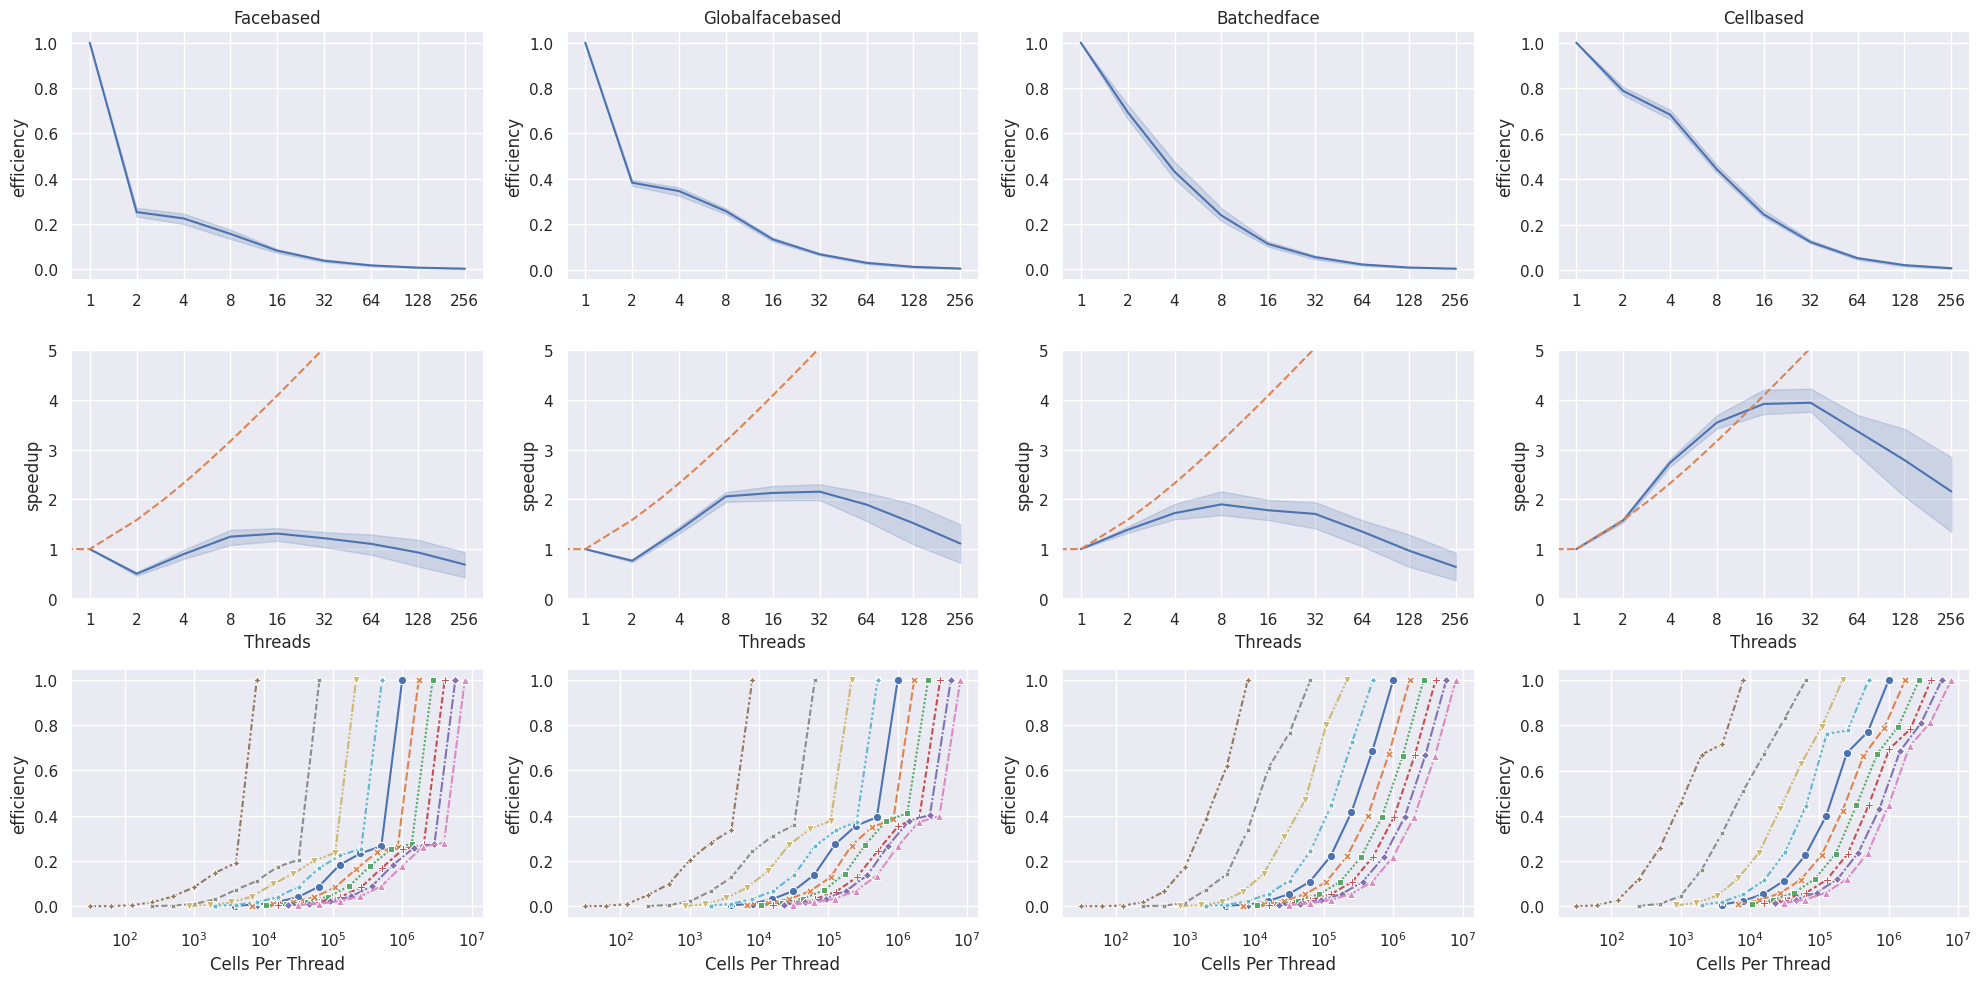

In [16]:
fig, axes = plt.subplots(3,4, figsize=(20, 10), sharey=False, sharex=False)

for i, strat in enumerate(strategies):
    plot = sb.lineplot(data=cpu[cpu["strategy"] == strat], x="logth", y="efficiency", ax=axes.flat[i])
    plot.set_title(strat.capitalize())
    plot.set_xticklabels(cpu["Threads"].unique())
    plot.set(
        xlabel=""
    )
    plot.set_xticks(cpu["logth"].unique())
    plot = sb.lineplot(data=cpu[cpu["strategy"] == strat], x="Threads", y="speedup", ax=axes.flat[i+4])
    axes.flat[i+4].plot([math.log2(x) for x in range(1,128)], linestyle="--", label="ideal")
    # plot.set(xscale="log")
    axes.flat[i+4].set_xscale('log', base=2)
    plot.set_ylim([0, 5])


    plot.set_xticks(cpu["Threads"].unique())
    plot.set_xticklabels(cpu["Threads"].unique())
    plot.set(
        xlabel="Threads"
    )
    plot = sb.lineplot(data=cpu[cpu["strategy"] == strat], x="cellsPerCpu", y="efficiency", ax=axes.flat[i+8], legend=False, markers=True, style="case_long", hue="case_long")
    plot.set(
        xlabel="Cells Per Thread"
    )
    plot.set(xscale="log")
    # plot.set_xticklabels(df["Threads"].unique())
    # plot.set_xticks(df["logth"].unique())
    # axes.flat[i+8].ticklabel_format(useOffset=False, style='plain')

plt.tight_layout()
plt.savefig("../figures/cpu_scaling.svg")

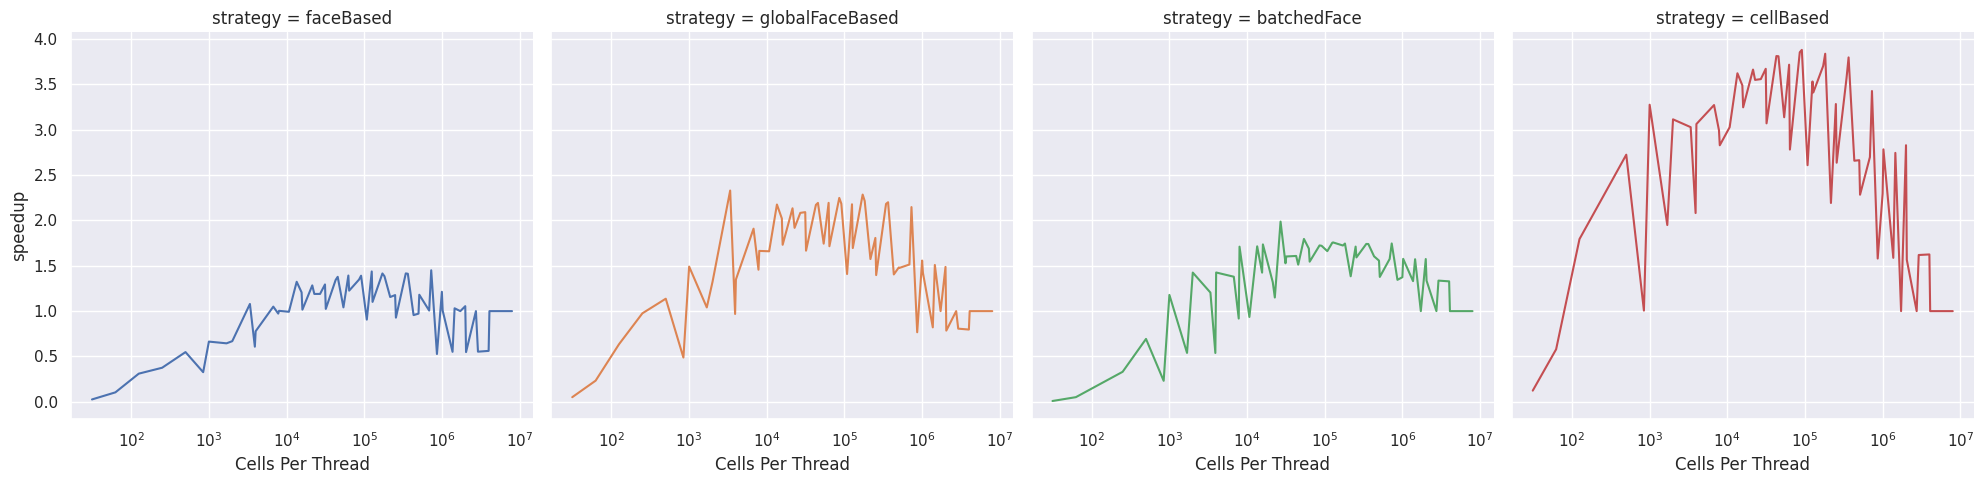

In [17]:
plot = sb.relplot(data=cpu, x="cellsPerCpu", y="speedup", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")
plt.tight_layout()

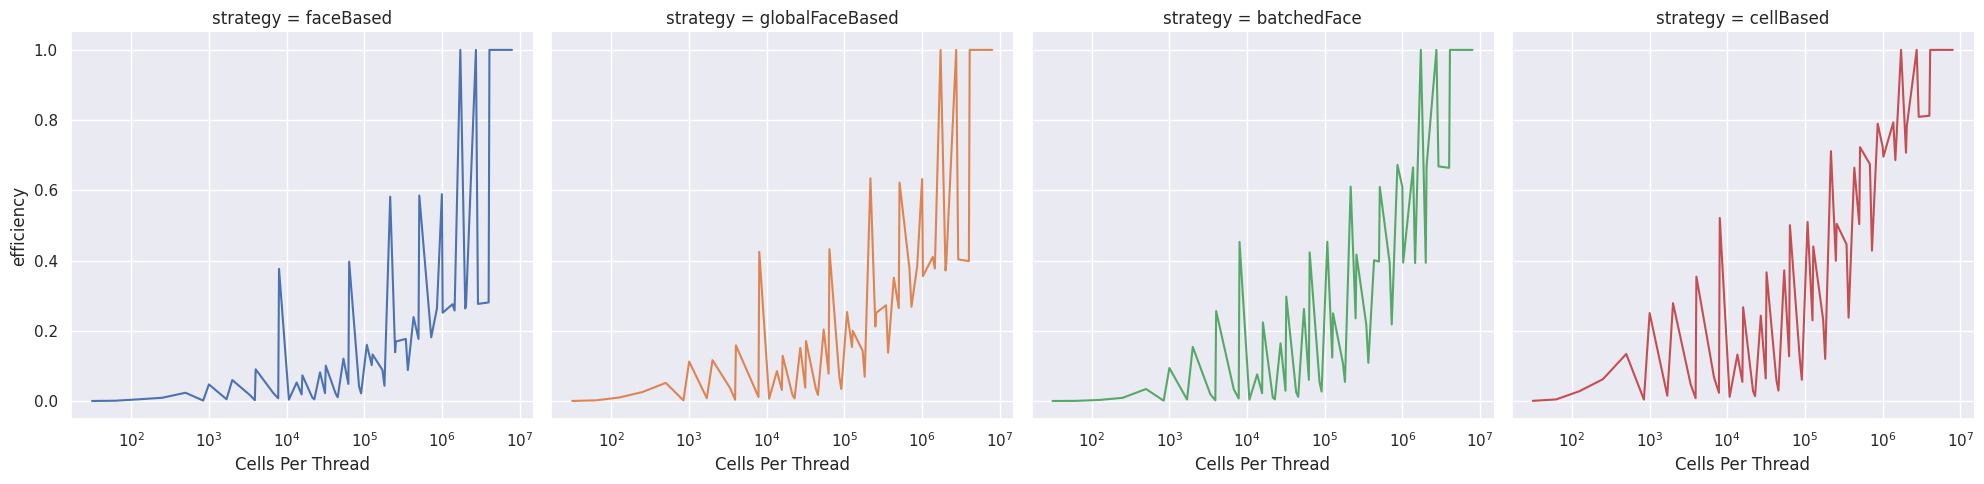

In [18]:
plot = sb.relplot(data=cpu, x="cellsPerCpu", y="efficiency", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")
plt.tight_layout()

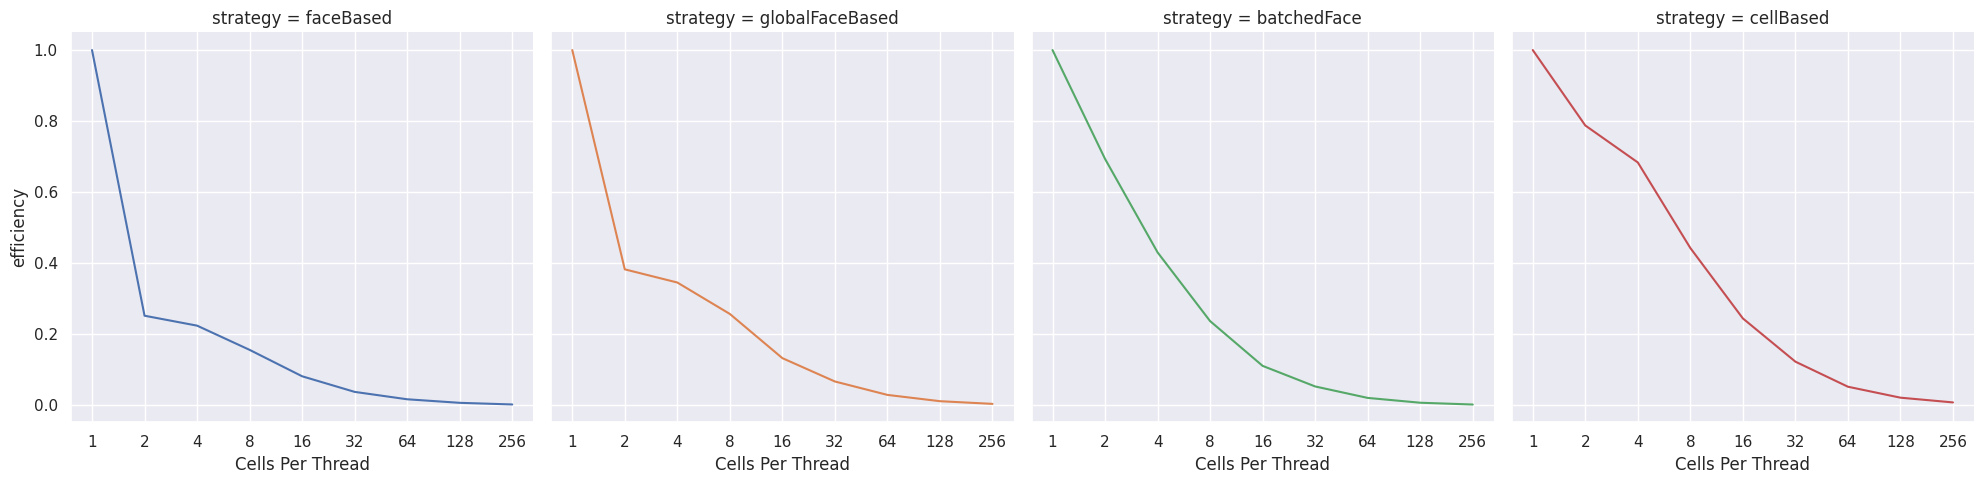

In [19]:
plot = sb.relplot(data=cpu, x="Threads", y="efficiency", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")
for ax in plot.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(cpu["Threads"].unique())

    ax.set_xticklabels(labels=cpu["Threads"].unique())

plt.tight_layout()

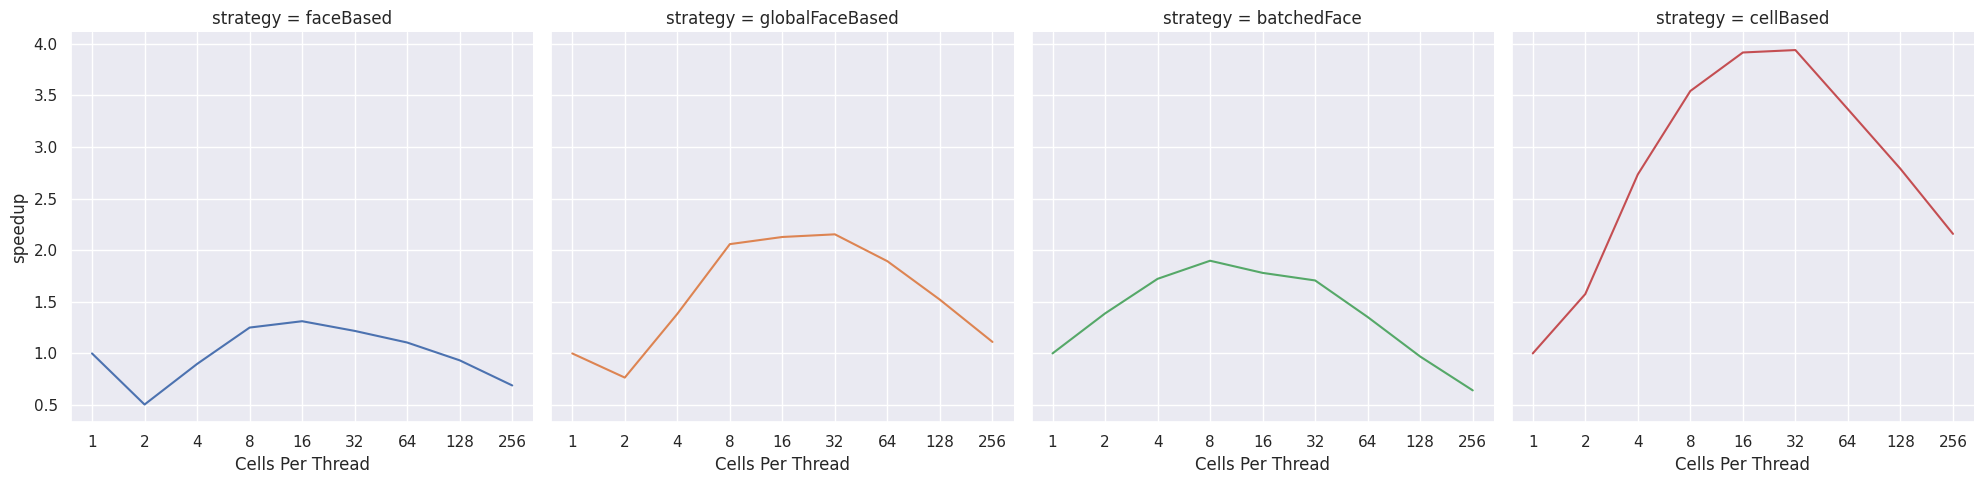

In [20]:
plot = sb.relplot(data=cpu, x="Threads", y="speedup", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")

for ax in plot.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(cpu["Threads"].unique())

    ax.set_xticklabels(labels=cpu["Threads"].unique())

plt.tight_layout()

In [23]:
cpu[cpu["case_long"] == "cases/Lid-Driven-Cavities/240/"]

,time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case_short,case_long,strategy,variant,language,precision,...,use_fusing,cells,ms_normed,Threads,cellsPerCpu,logth,serial_time,speedup,efficiency,logthp1


In [21]:
plot = sb.relplot(data=cpu[cpu["case_long"] == "cases/Lid-Driven-Cavities/240/"], x="Threads", y="speedup", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")

for ax in plot.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(cpu["Threads"].unique())

    ax.set_xticklabels(labels=cpu["Threads"].unique())

plt.tight_layout()

KeyError: 'strategy'

In [ ]:
plot = sb.relplot(data=cpu[cpu["case_long"] == "cases/Lid-Driven-Cavities/240/"], x="Threads", y="time_mean_ms", hue="strategy", kind="line", err_style=None, col="strategy", legend=False)
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")

for ax in plot.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(cpu["Threads"].unique())

    ax.set_xticklabels(labels=cpu["Threads"].unique())

plt.tight_layout()

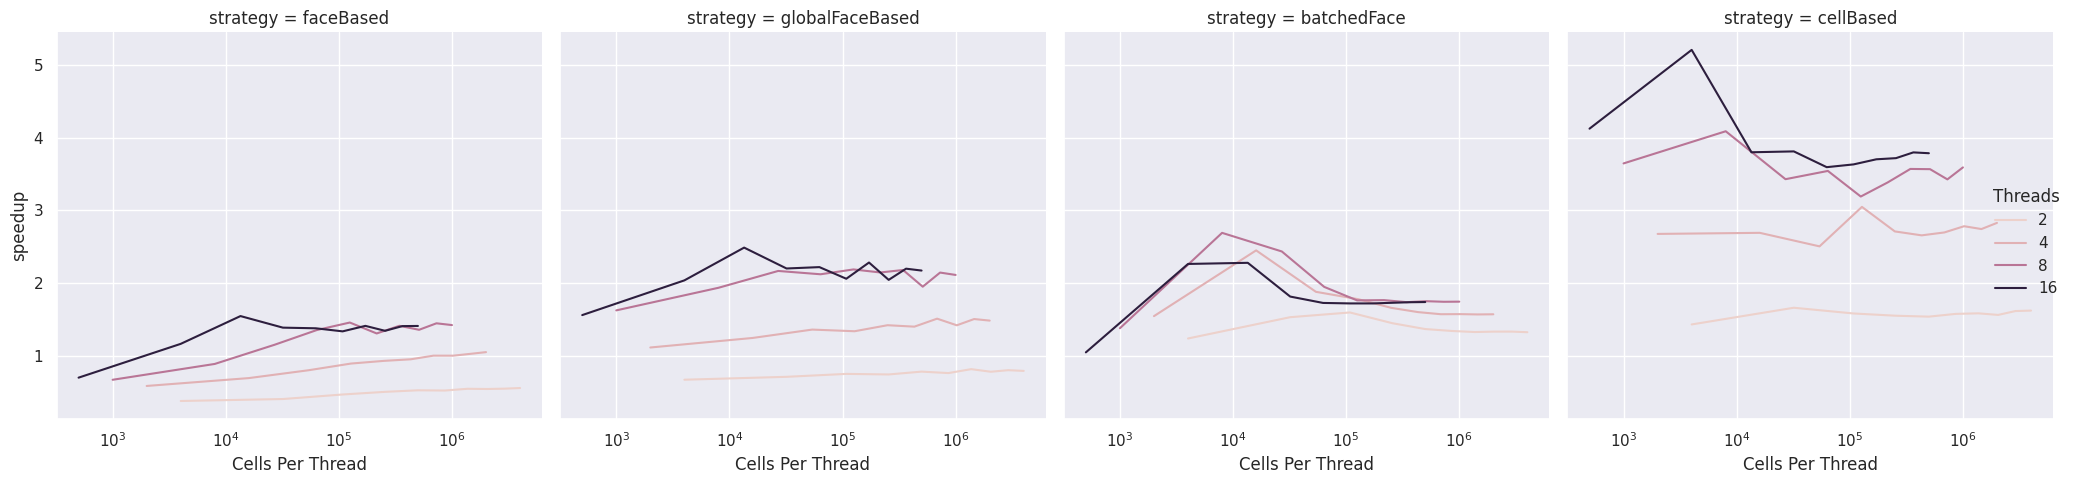

In [24]:
plot = sb.relplot(data=cpu[(cpu["Threads"] <= 16) & (cpu["Threads"] > 1)], x="cellsPerCpu", y="speedup", hue="Threads", kind="line", err_style=None, col="strategy", facet_kws={'sharey': True, 'sharex': True})
plot.set(
    xlabel="Cells Per Thread"
)
plot.set(xscale="log")

# for ax in plot.axes.flat:
#     labels = ax.get_xticklabels() # get x labels
#     ax.set_xticks(df["Threads"].unique())

#     ax.set_xticklabels(labels=df["Threads"].unique())

plt.tight_layout()

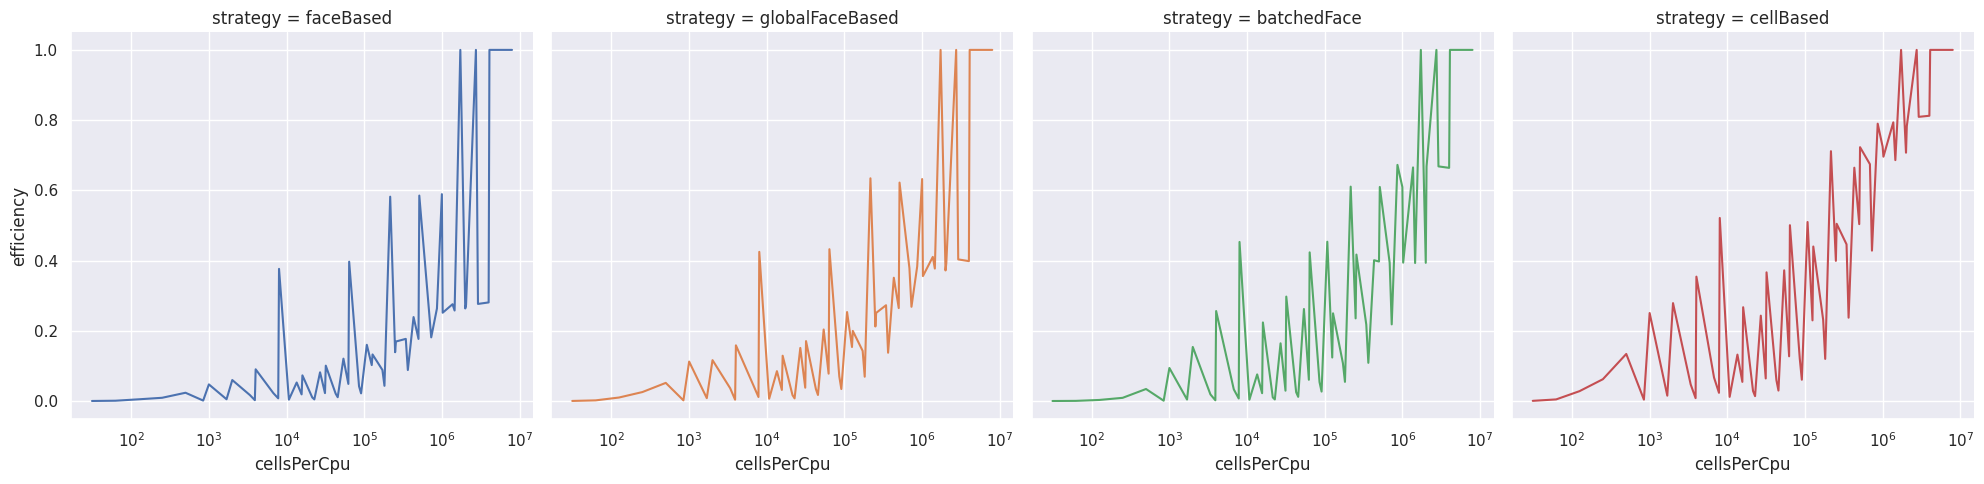

In [25]:
yvar = "speedup"

plot = sb.relplot(data=cpu, x="cellsPerCpu", y="efficiency", hue="strategy", kind="line", col="strategy", legend=False, err_style=None,)
axes = plot.axes.flat
T = cpu["Threads"].unique()
# plot.set(xlabel="Threads")
# for ax in axes:
#     ax.set_xticks(list(range(1,9)))
#     ax.set_xticklabels(labels=T)
#     ax.plot([1,7], [1,7], color='r',linestyle="dashed")
#     ax.set_yticks(list(range(1,9)))
#     ax.set_yticklabels(labels=T)
# for col_val, ax in plot.axes_dict.items():
#     ax1 = ax.twinx()
#     ax1.grid(False)
#     sb.lineplot(data=df[df['strategy'] == col_val], x="logthp1", y="efficiency", ax=ax1, color="gray",)
#     ax1.set_ylabel('')
#     # subset data for this facet
#     sub = df[
#         (df["strategy"] == col_val)
#     ]

    # if not sub.empty:
    #     # find row with max y
    #     # idx = sub[sub["Threads"] != 1]["efficiency"].idxmax()
    #     # max_row = sub.loc[idx]
    #     # print(f"drawing for {row_val},{col_val} at {max_row["logthp1"]},{max_row[yvar]}")
    #     # annotate
    #     ax.text(
    #         max_row["logthp1"],
    #         max_row[yvar],
    #         f"{round(max_row[yvar], 3)}",
    #         color="black",
    #         fontsize=9,
    #         ha="left",
    #         va="bottom"
    #     )
    #     ax.scatter(
    #         max_row["logthp1"],
    #         max_row[yvar],
    #         color="red",
    #         s=50,
    #         zorder=5
    #     )
plt.xscale("log")
plt.tight_layout()

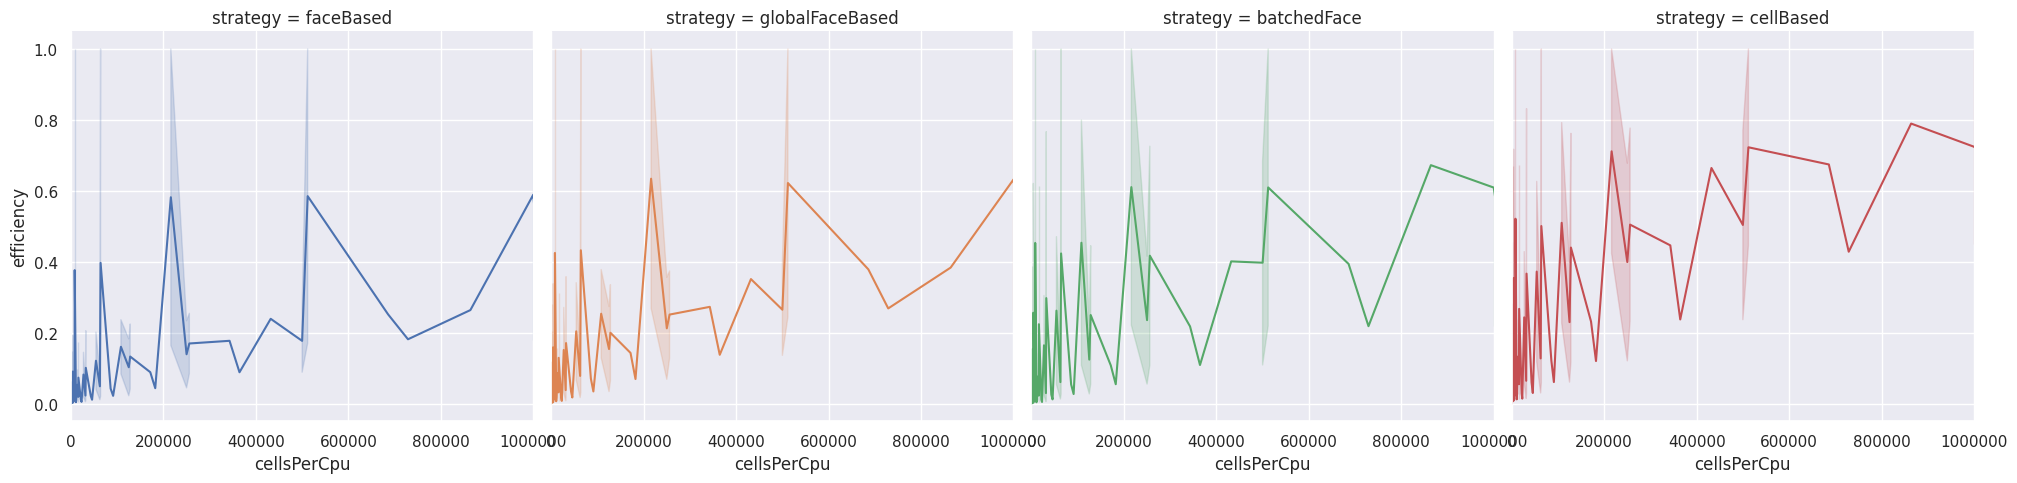

In [26]:
plot = sb.relplot(data=cpu, x="cellsPerCpu", y="efficiency", hue="strategy", kind="line", col="strategy", legend=False)
axes = plot.axes.flat
T = cpu["Threads"].unique()
# plot.set(xscale="log")
plt.xlim([0, 1000000])
for ax in axes:
    labels = ax.get_xticklabels() # get x labels
plt.gca().ticklabel_format(axis='x', style='plain')


In [27]:
bins = [0, 50000, 100000, 300000, 500000, max(cpu["cellsPerCpu"])]
labels = ['0-50k', '50k-100k', '100k-300k', '300k-500k', '500k+']

cpu['CPTranges'] = pd.cut(cpu['cellsPerCpu'], bins=bins, labels=labels)

ValueError: The number of FixedLocator locations (8), usually from a call to set_ticks, does not match the number of labels (9).

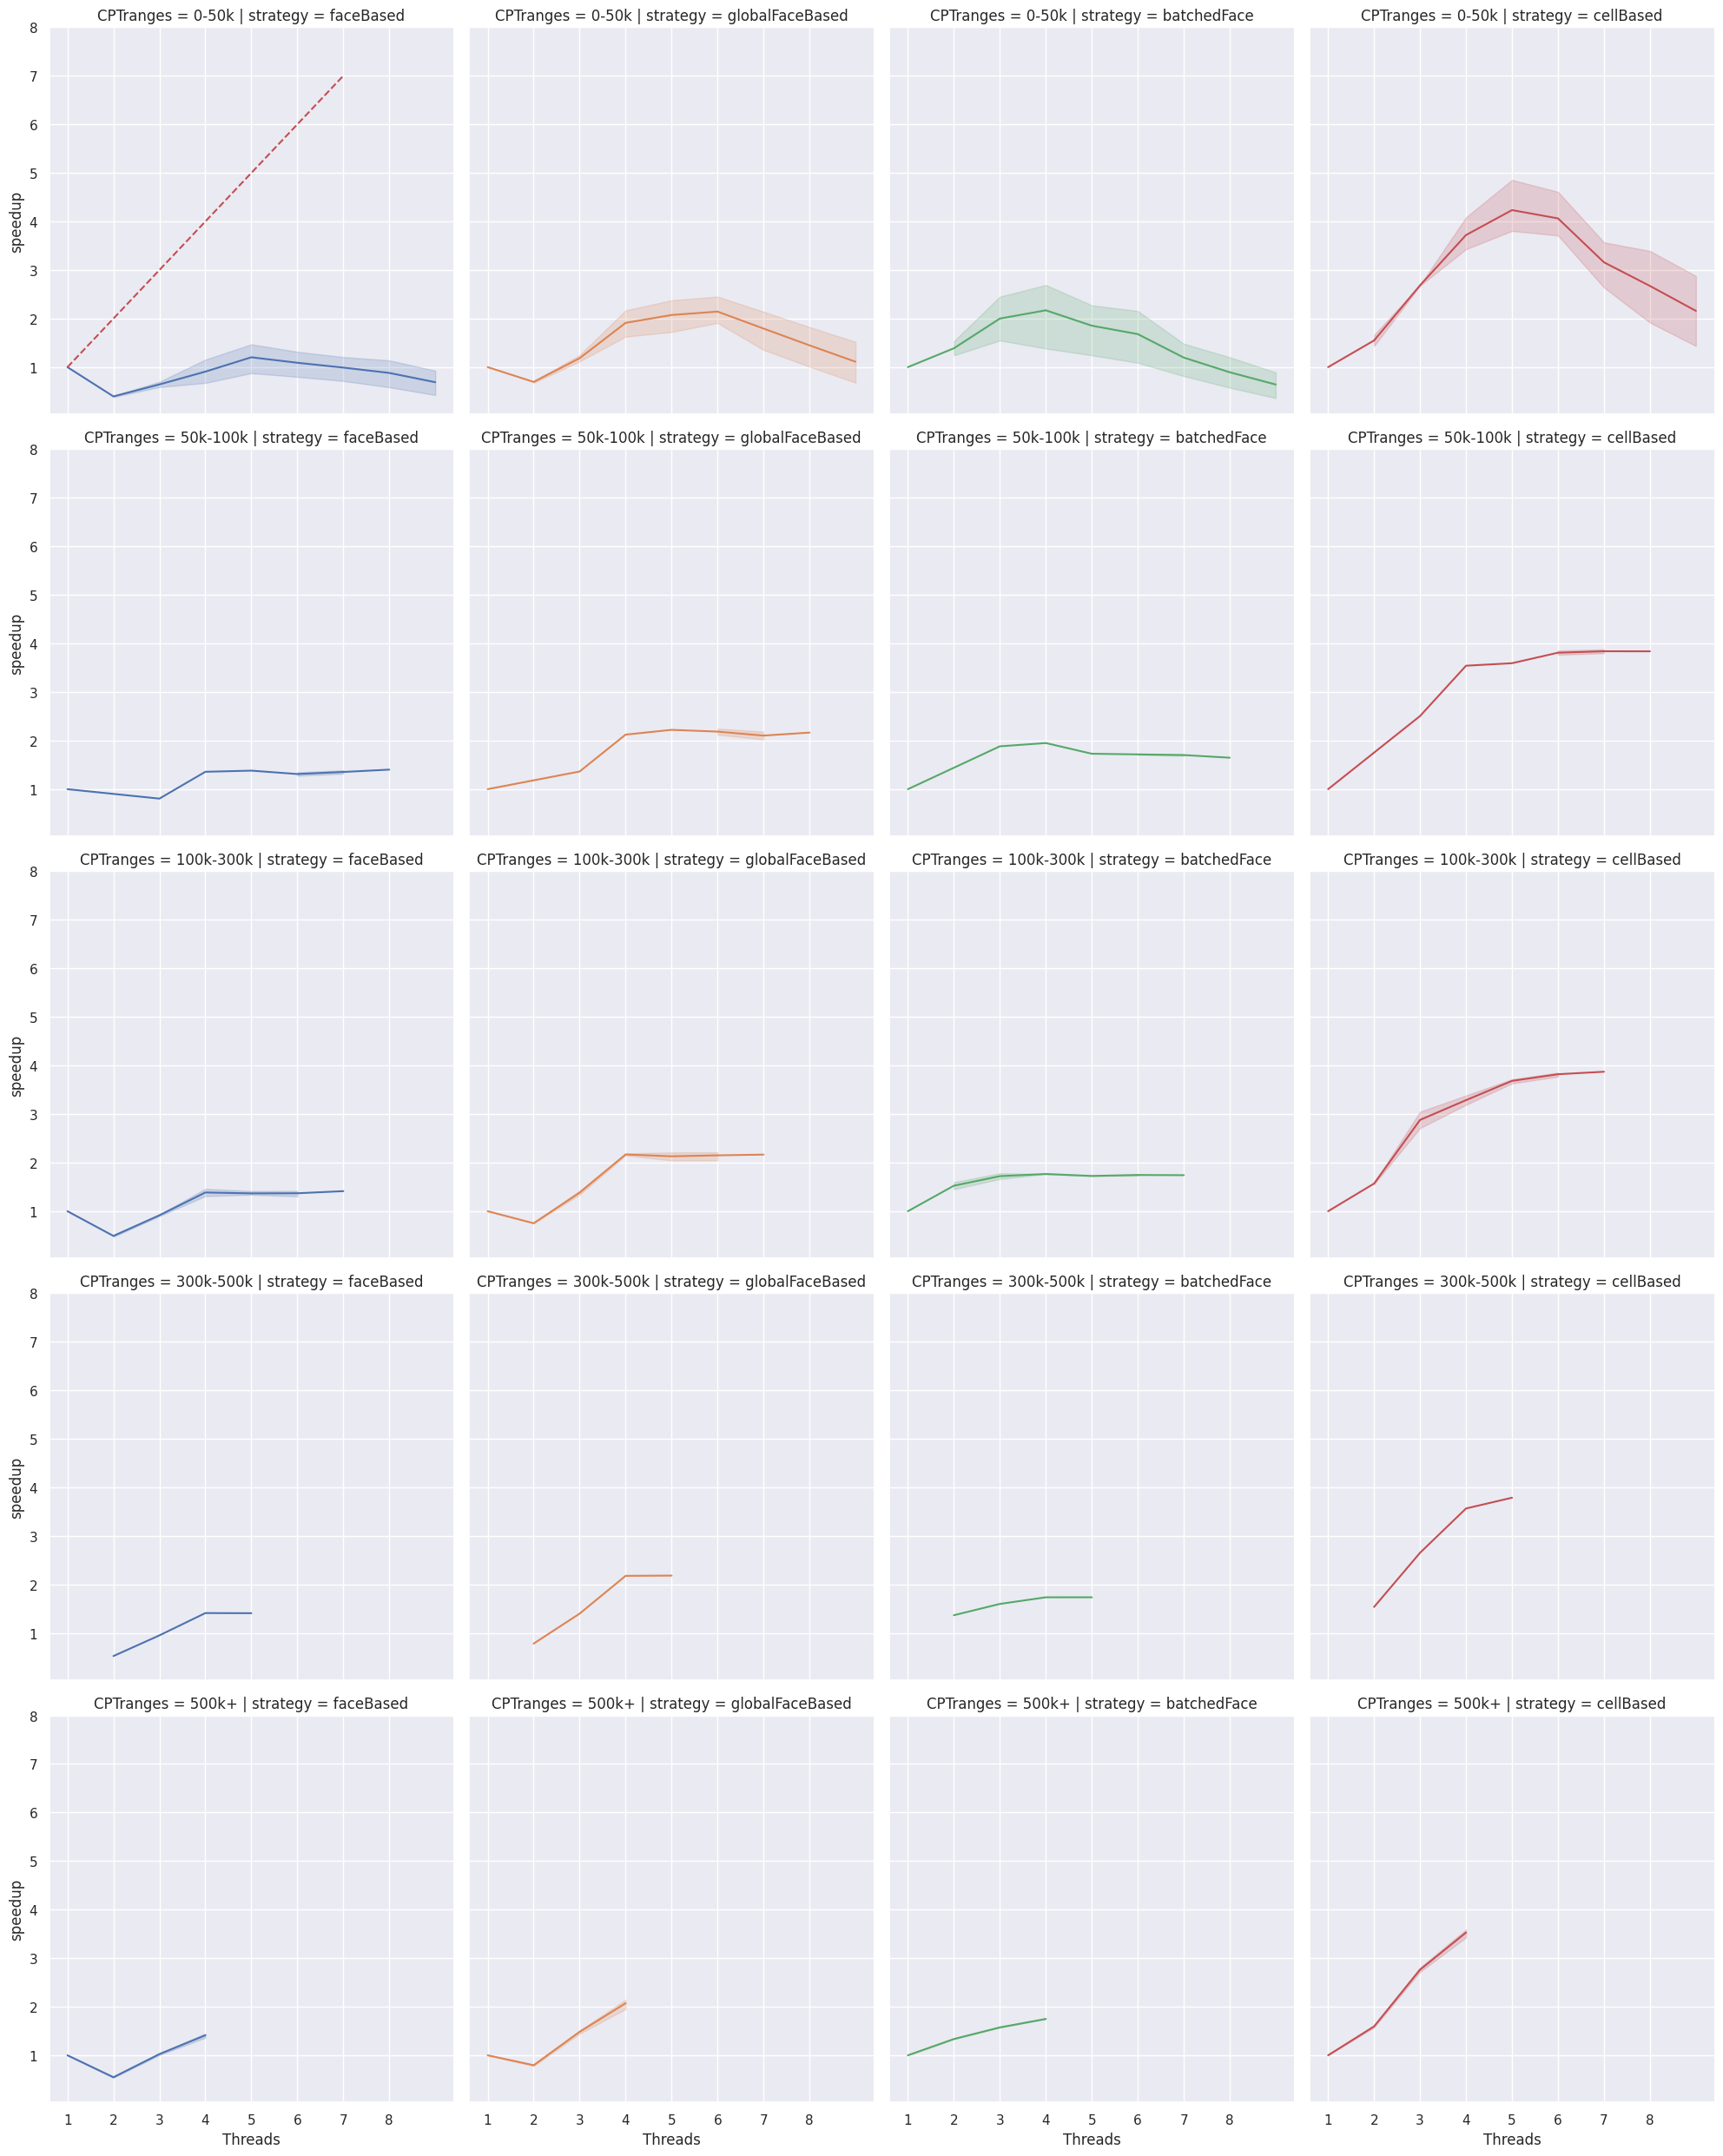

In [28]:
yvar = "speedup"
plot = sb.relplot(data=cpu, x="logthp1", y=yvar, hue="strategy", kind="line", col="strategy", row="CPTranges", legend=False)
axes = plot.axes.flat
T = cpu["Threads"].unique()
plot.set(xlabel="Threads")
for ax in axes:
    ax.set_xticks(list(range(1,9)))
    # ax.set_xticklabels(labels=T)
    ax.plot([1,7], [1,7], color='r',linestyle="dashed")
    ax.set_yticks(list(range(1,9)))
    ax.set_yticklabels(labels=T)
max_df = cpu.loc[cpu.groupby(['CPTranges', 'strategy'])['speedup'].idxmax()]
print(f"{len(max_df)} == {len(axes)}")
plt.xlim([0, 10])
# Loop through each facet
for (row_val, col_val), ax in plot.axes_dict.items():
    # subset data for this facet
    sub = cpu[
        (cpu["CPTranges"] == row_val) &
        (cpu["strategy"] == col_val)
    ]

    if not sub.empty:
        # find row with max y
        idx = sub[sub["Threads"] != 1]["efficiency"].idxmax()
        max_row = sub.loc[idx]
        print(f"drawing for {row_val},{col_val} at {max_row["logthp1"]},{max_row[yvar]}")
        # annotate
        ax.text(
            max_row["logthp1"],
            max_row[yvar],
            f"{round(max_row[yvar], 3)}",
            color="black",
            fontsize=9,
            ha="left",
            va="bottom"
        )
        ax.scatter(
            max_row["logthp1"],
            max_row[yvar],
            color="red",
            s=50,
            zorder=5
        )

In [ ]:
print(cpu["logth"].unique())
print(cpu["Threads"].unique())

In [ ]:
cpu

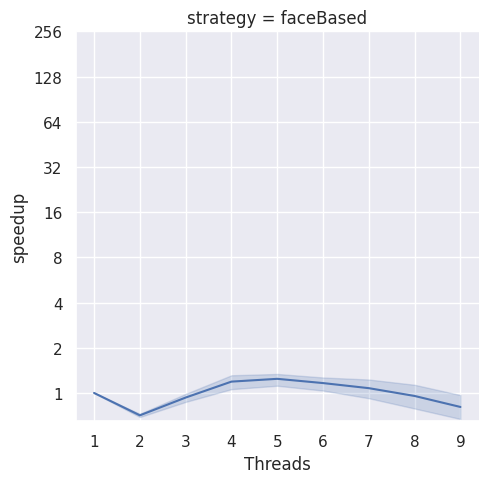

In [29]:
yvar = "speedup"
plot = sb.relplot(data=cpu[cpu["variant"].str.contains("SOAFusedFaceBased")], x="logthp1", y=yvar, hue="strategy", kind="line", col="strategy", legend=False)
T = cpu["Threads"].unique()
axes = plot.axes.flat
plot.set(xlabel="Threads")
for ax in axes:
    ax.set_xticks(list(range(1,10)))
    # ax.set_xticklabels(labels=T)
    # ax.plot([1,10], [1,10], color='r',linestyle="dashed")
    ax.set_yticks(list(range(1,10)))
    ax.set_yticklabels(labels=T)


20 == 1


(0.0, 10.0)

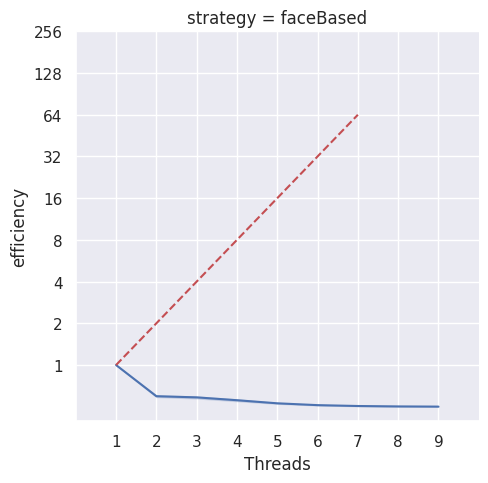

In [31]:
yvar = "efficiency"
plot = sb.relplot(data=cpu[cpu["variant"].str.contains("SOAFusedFaceBased")], x="logthp1", y=yvar, hue="strategy", kind="line", col="strategy", legend=False)
axes = plot.axes.flat
T = cpu["Threads"].unique()
plot.set(xlabel="Threads")
for ax in axes:
    ax.set_xticks(list(range(1,10)))
    # ax.set_xticklabels(labels=T)
    ax.plot([1,7], [1,7], color='r',linestyle="dashed")
    ax.set_yticks(list(range(1,10)))
    ax.set_yticklabels(labels=T)
max_df = cpu.loc[cpu.groupby(['CPTranges', 'strategy'])['speedup'].idxmax()]
print(f"{len(max_df)} == {len(axes)}")
plt.xlim([0, 10])
# Loop through each facet
# for (row_val, col_val), ax in plot.axes_dict.items():
#     # subset data for this facet
#     sub = df[
#         (df["CPTranges"] == row_val) &
#         (df["strategy"] == col_val)
#     ]

#     if not sub.empty:
#         # find row with max y
#         idx = sub[sub["Threads"] != 1]["efficiency"].idxmax()
#         max_row = sub.loc[idx]
#         print(f"drawing for {row_val},{col_val} at {max_row["logthp1"]},{max_row[yvar]}")
#         # annotate
#         ax.text(
#             max_row["logthp1"],
#             max_row[yvar],
#             f"{round(max_row[yvar], 3)}",
#             color="black",
#             fontsize=9,
#             ha="left",
#             va="bottom"
#         )
#         ax.scatter(
#             max_row["logthp1"],
#             max_row[yvar],
#             color="red",
#             s=50,
#             zorder=5
#         )

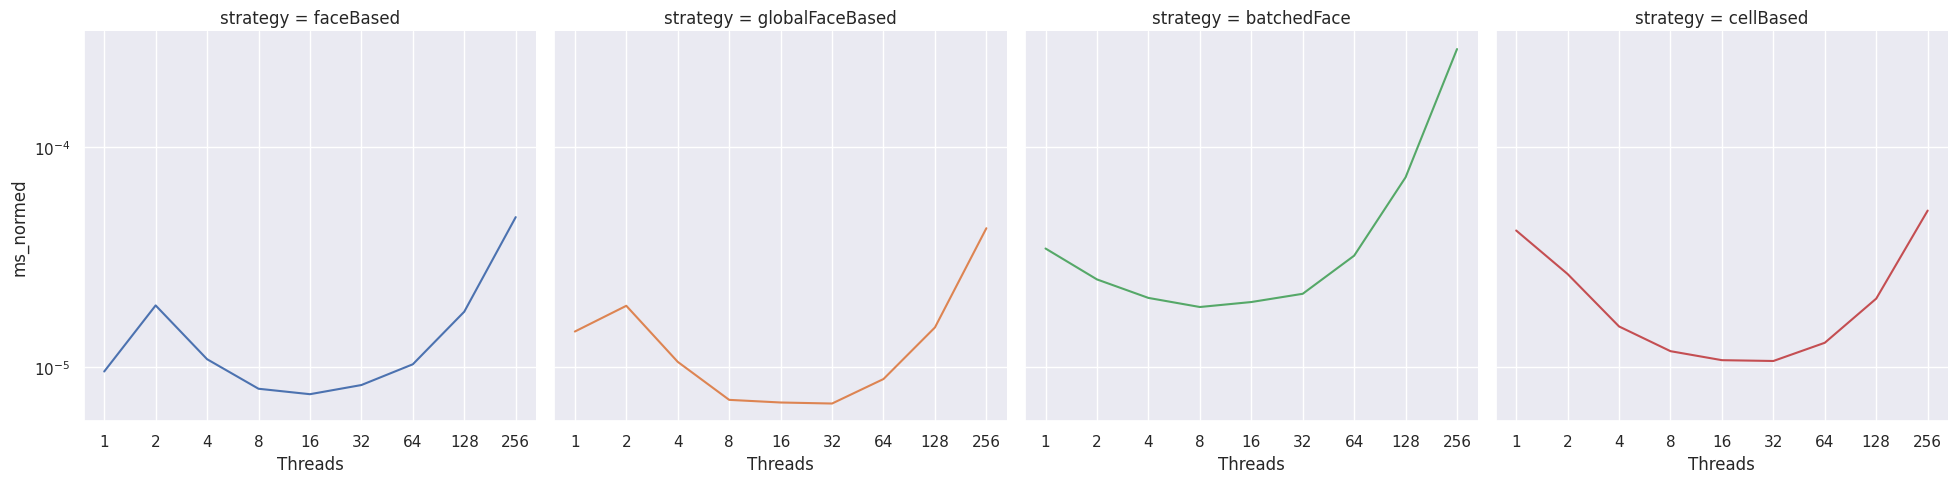

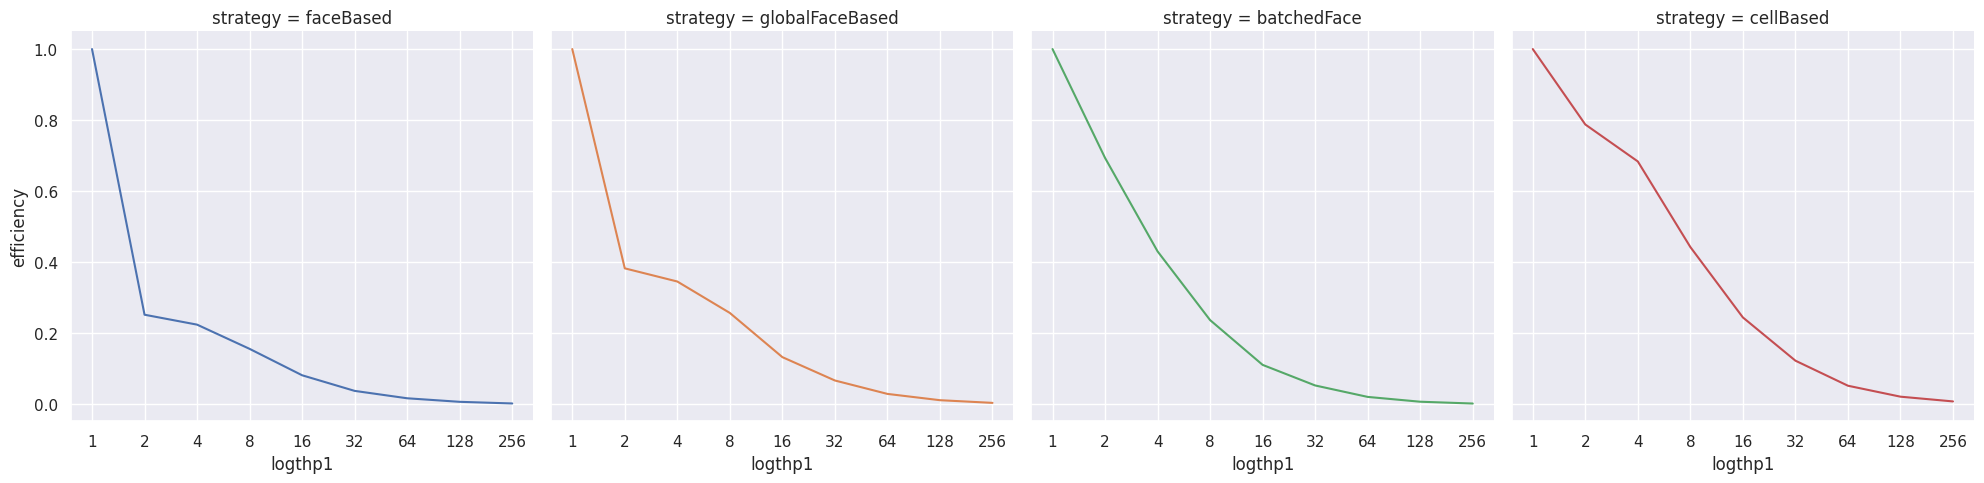

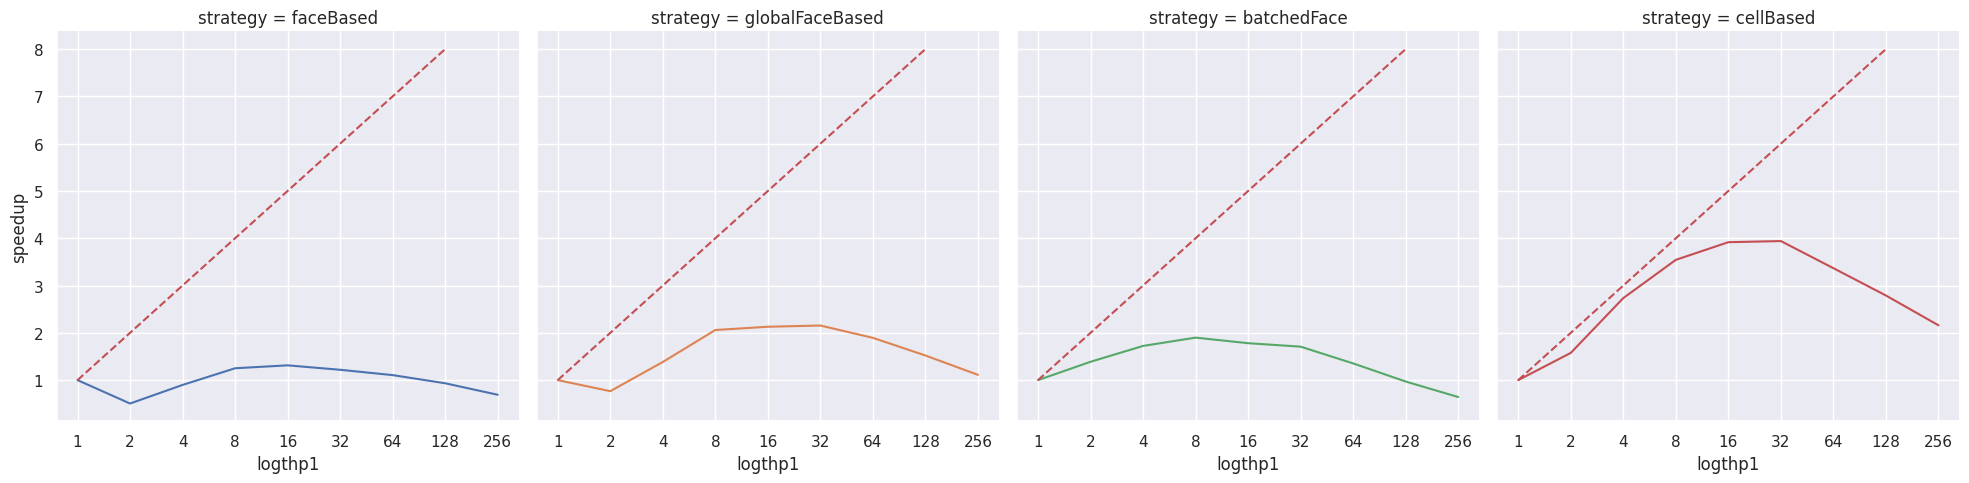

In [32]:
yvar = "ms_normed"
plot = sb.relplot(data=cpu[cpu["Threads"] != 0], x="logthp1", y=yvar, hue="strategy", kind="line", err_style=None,col="strategy", legend=False)
axes = plot.axes.flat
T = cpu["Threads"].unique()
plot.set(xlabel="Threads")
plt.yscale("log")
for ax in axes:
    ax.set_xticks(list(range(1,10)))
    ax.set_xticklabels(labels=T)
    # ax.plot([2,8], [2,8], color='r',linestyle="dashed")
    # ax.set_yticks(list(range(1,10)))
    # ax.set_yticklabels(labels=T)
max_df = cpu.loc[cpu.groupby(['CPTranges', 'strategy'])['speedup'].idxmax()]

plot2 = sb.relplot(data=cpu[cpu["Threads"] != 0], x="logthp1", y="efficiency", hue="strategy", kind="line", err_style=None,col="strategy", legend=False)
for ax in plot2.axes.flat:
    ax.set_xticks(list(range(1,10)))
    ax.set_xticklabels(labels=T)
plot3 = sb.relplot(data=cpu[cpu["Threads"] != 0], x="logthp1", y="speedup", hue="strategy", kind="line", err_style=None,col="strategy", legend=False)

for ax in plot3.axes.flat:
    ax.set_xticks(list(range(1,10)))
    ax.set_xticklabels(labels=T)
    ax.plot([1,8], [1,8], color='r',linestyle="dashed")
    # ax.set_yticks(list(range(1,10)))
    # ax.set_yticklabels(labels=T)

In [33]:
cpu["case_num"] = cpu["case_long"].str.extract(r'(\d+)/?$').astype(int)

# build sorted order
order = (
    cpu[["case_long", "case_num"]]
    .drop_duplicates()
    .sort_values("case_num")
    ["case_long"]
)

In [34]:
ncells = sorted((round(cpu["cells"]**(1/3))).unique().astype(int))
strats  =['faceBased', 'globalFaceBased', 'batchedFace', 'cellBased']

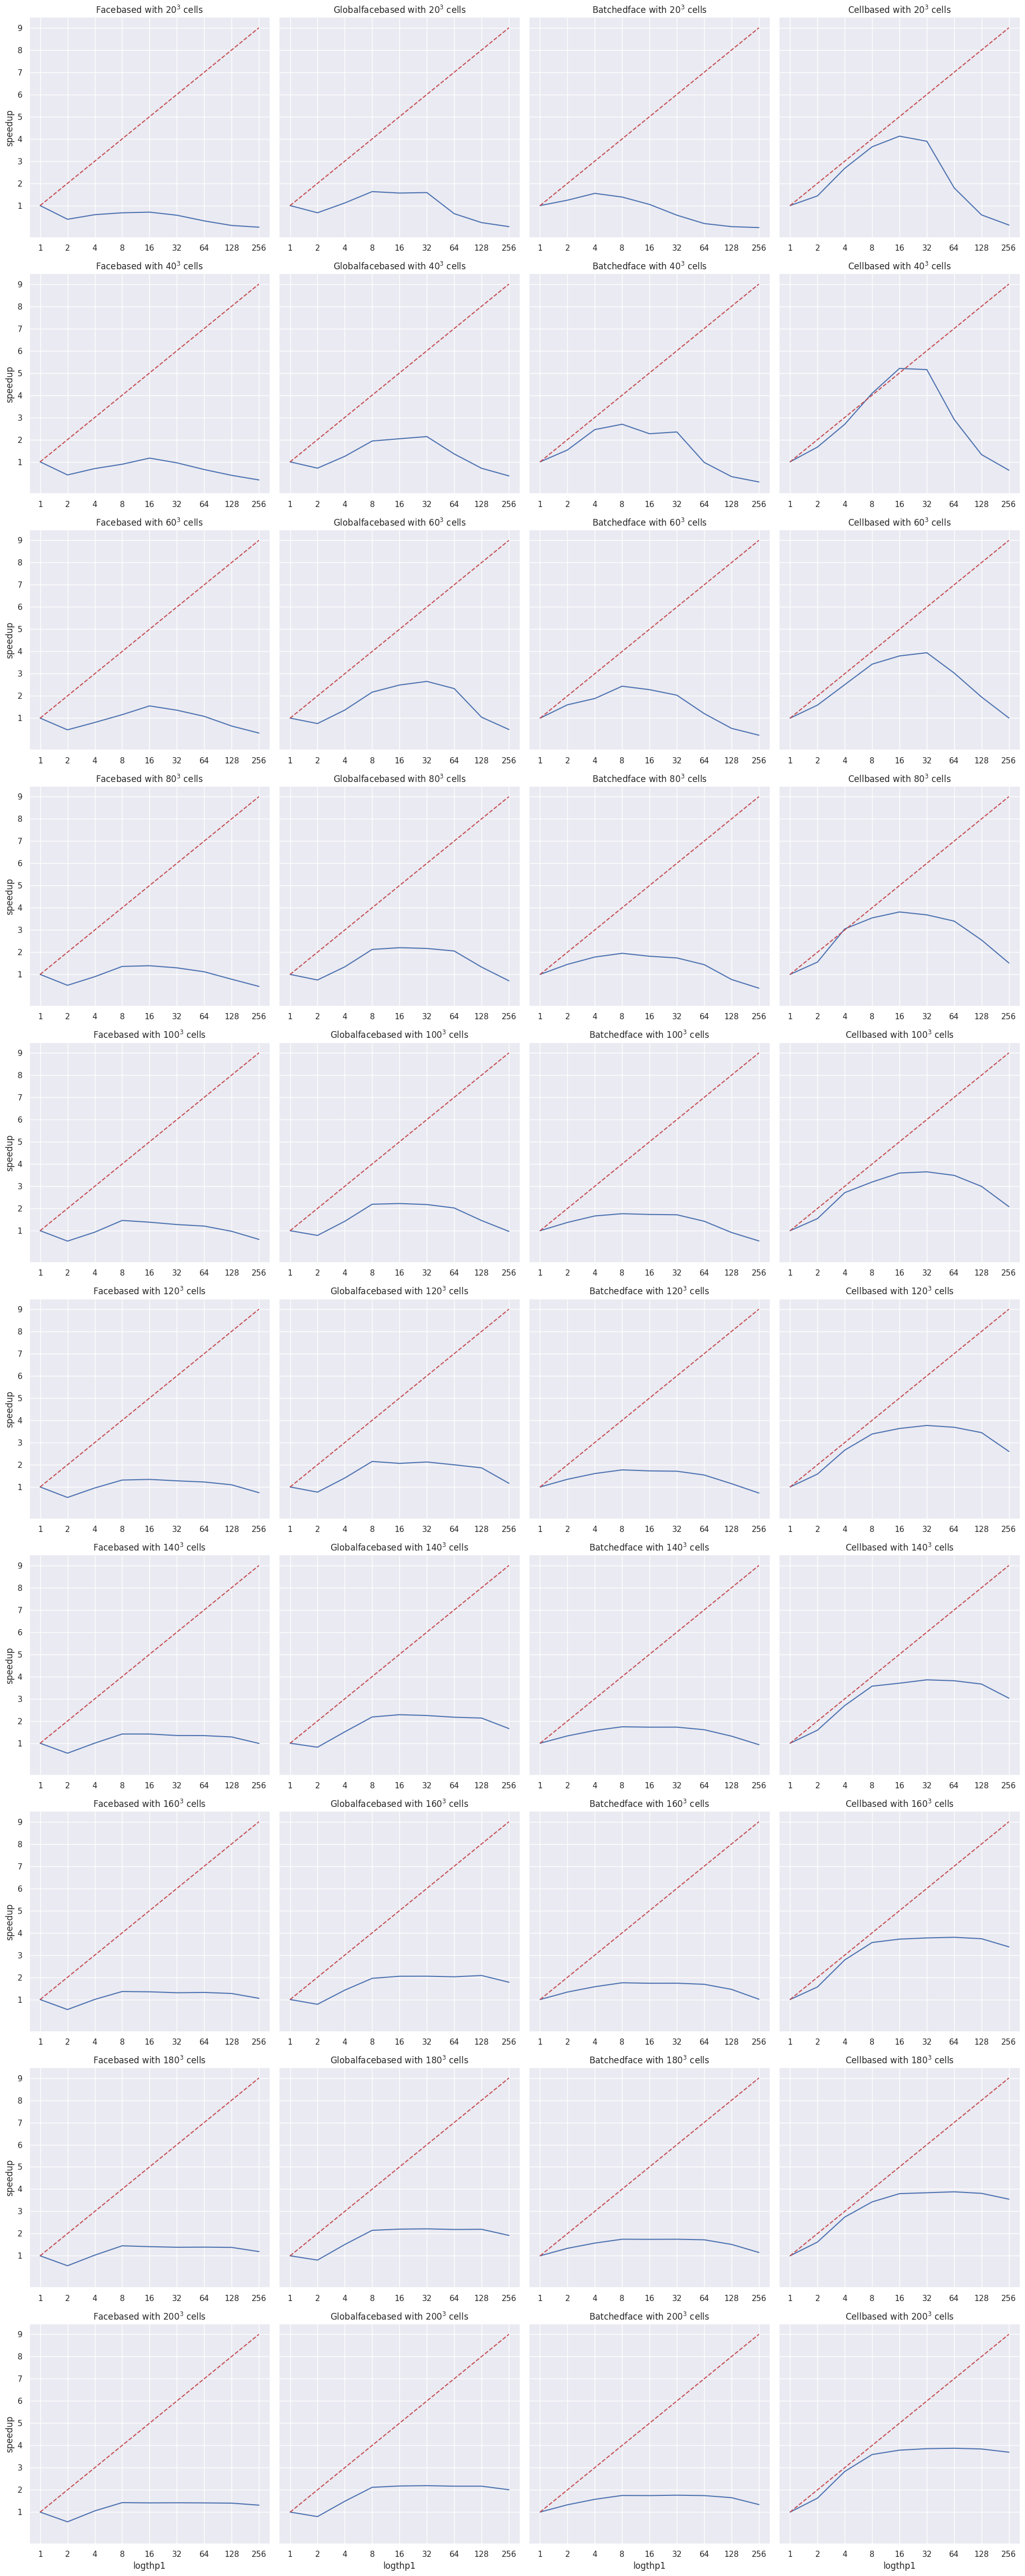

In [35]:
plot = sb.relplot(data=cpu, x="logthp1", y="speedup", kind="line", col="strategy", row="case_long", row_order=order, col_order=strats)
axes = plot.axes
for i in range(len(order)):
    for j in range(4):
        ax = axes[i,j]
        ax.set_title(f"{strats[j].capitalize()} with ${ncells[i]}^3$ cells")
        ax.tick_params(labelbottom=True)
        ax.set_xticks(list(range(1,10)))
        ax.set_xticklabels(labels=cpu["Threads"].unique())
        ax.plot([1,9], [1,9], color='r',linestyle="dashed")
        ax.set_yticks(list(range(1,10)))
        # ax.set_yticklabels(labels=T)
plt.tight_layout()

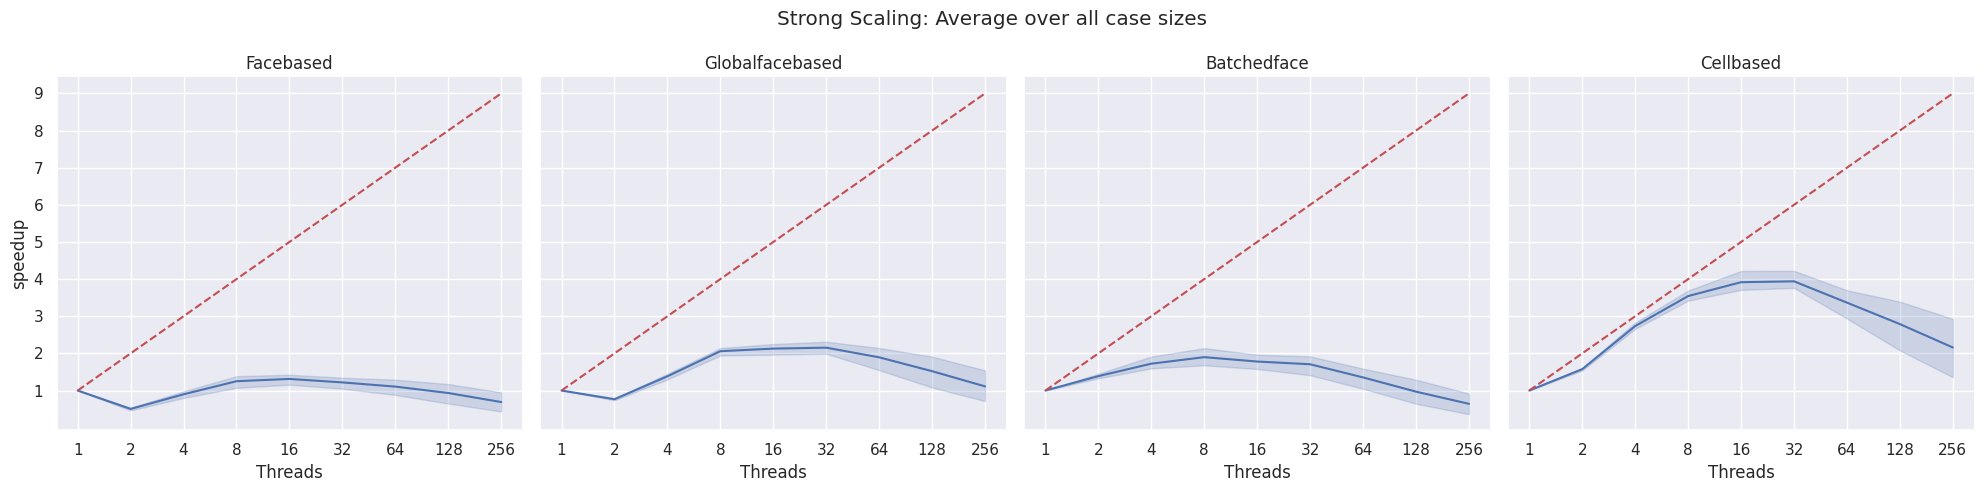

In [36]:
plot = sb.relplot(data=cpu, x="logthp1", y="speedup", kind="line", col="strategy",  col_order=strats)
axes = plot.axes.flat

for i, ax in enumerate(axes):
    ax.set_title(f"{strats[i].capitalize()}")
    ax.tick_params(labelbottom=True)
    ax.set_xticks(list(range(1,10)))
    ax.set_xticklabels(labels=cpu["Threads"].unique())
    ax.set_xlabel("Threads")
    ax.plot([1,9], [1,9], color='r',linestyle="dashed")
    ax.set_yticks(list(range(1,10)))
    # ax.set_yticklabels(labels=T)
plt.suptitle("Strong Scaling: Average over all case sizes")
plt.tight_layout()